## Masking and Patching

We visualize how to create prediction and context masks with `IJEPAMasker`.

In [1]:
import einops
import jax
import matplotlib.pyplot as plt
from jax import numpy as jnp
from jepax.data import build_dataloader

dataloader, _, _, _ = build_dataloader("CIFAR10", data_dir="~/data")
batch = next(iter(dataloader))
x = jnp.transpose(batch["image"], (0, 2, 3, 1))
y = batch["label"]

/home/ubuntu/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/home/ubuntu/.local/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


## Helpers

Define helper functions to convert images to patch features by reshaping. Allows us to simulate applying a mask to a sequence of tokens.

In [2]:
PATCH_SIZE = 2
IMG_H, IMG_W = 32, 32
N_PATCH = IMG_H // PATCH_SIZE  # =16 here
M = 4


def patchify(x, patch_size):
    return einops.rearrange(
        x,
        "(h ph) (w pw) c -> (h w) (c ph pw)",
        ph=patch_size,
        pw=patch_size,
    )


def unpatchify(x, patch_size, n_patch):
    return einops.rearrange(
        x,
        "(h w) (c ph pw) -> (h ph) (w pw) c",
        h=n_patch,
        ph=patch_size,
        pw=patch_size,
    )


def visualize_mask(x, mask, patch_size, n_patch):
    x_masked = jax.vmap(lambda x, m: x * m)(patchify(x, patch_size), mask)
    return unpatchify(x_masked, patch_size, n_patch)


def set_token_mask(tokens, mask, mask_vec):
    return jnp.where(mask[..., None], tokens, mask_vec)

## Sample masks

Sample boolean prediction and context masks, where `True` represents keeping a patch in the encoder
- `mask_ctx` is a `(n_patch**2,)` boolean array
- `mask_pred` is a  `(M, n_patch**2)` boolean array, where `M` is the number of predictor masks

In [3]:
from jepax.model.masker import IJEPAMasker

masker = IJEPAMasker(
    IMG_H,
    IMG_W,
    PATCH_SIZE,
    ctx_scale=0.9,
    pred_scale=(0.1, 0.2),
    pred_aspect=(0.75, 1.2),
)
mask_ctx, mask_pred = masker(jax.random.PRNGKey(1), M, flatten=True)

## Visualize

Visualize the sampled masks

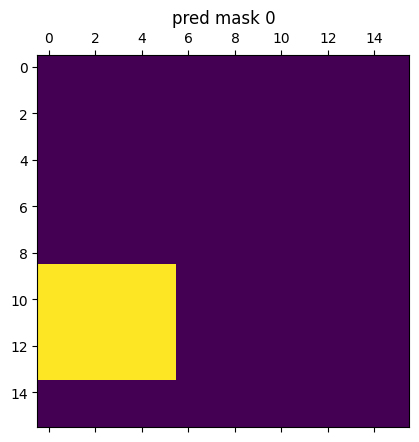

In [4]:
# Single prediction mask
plt.matshow(mask_pred[1].reshape(N_PATCH, N_PATCH))
plt.title("pred mask 0")
plt.show()

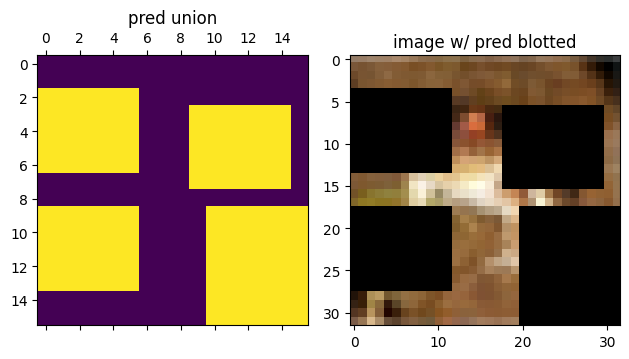

In [5]:
# Union of all prediction masks
mask_pred_union = jnp.any(mask_pred, axis=0)

fig, ax = plt.subplots(1, 2)
ax[0].matshow(mask_pred_union.reshape(N_PATCH, N_PATCH))
ax[0].set_title("pred union")
ax[1].imshow(visualize_mask(x[0], ~mask_pred_union, PATCH_SIZE, N_PATCH))
ax[1].set_title("image w/ pred blotted")
plt.tight_layout()
plt.show()

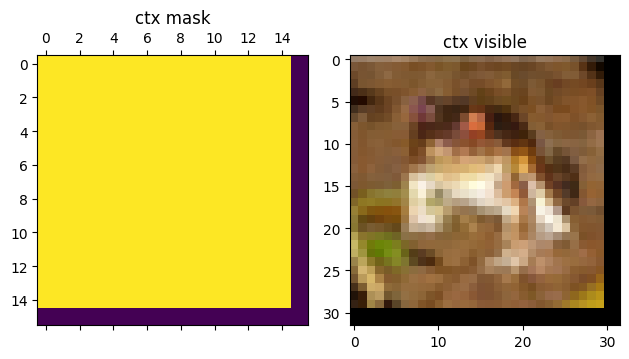

In [6]:
# Context mask
fig, ax = plt.subplots(1, 2)
ax[0].matshow(mask_ctx.reshape(N_PATCH, N_PATCH))
ax[0].set_title("ctx mask")
ax[1].imshow(visualize_mask(x[0], mask_ctx, PATCH_SIZE, N_PATCH))
ax[1].set_title("ctx visible")
plt.tight_layout()
plt.show()

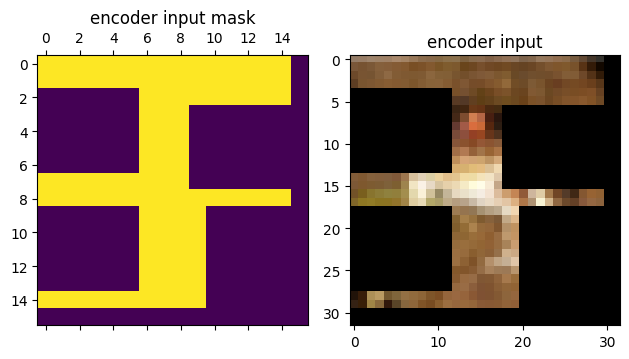

In [7]:
# what the encoder actually sees
mask_total = ~(~mask_ctx | mask_pred_union)

fig, ax = plt.subplots(1, 2)
ax[0].matshow(mask_total.reshape(N_PATCH, N_PATCH))
ax[0].set_title("encoder input mask")
ax[1].imshow(visualize_mask(x[0], mask_total, PATCH_SIZE, N_PATCH))
ax[1].set_title("encoder input")
plt.tight_layout()
plt.show()